In [1]:
import numpy as np
import matplotlib.pyplot as plt


Entropy H(i):
Position 1: 2.0000
Position 2: 1.6031
Position 3: 0.8758
Position 4: 1.0309
Position 5: 0.2343
Position 6: 0.2343
Position 7: 1.4480
Position 8: 1.0253
Position 9: 0.8758
Position 10: 1.0309
Position 11: 2.0000

Information content IC(i):
Position 1: 0.0000
Position 2: 0.3969
Position 3: 1.1242
Position 4: 0.9691
Position 5: 1.7657
Position 6: 1.7657
Position 7: 0.5520
Position 8: 0.9747
Position 9: 1.1242
Position 10: 0.9691
Position 11: 0.0000


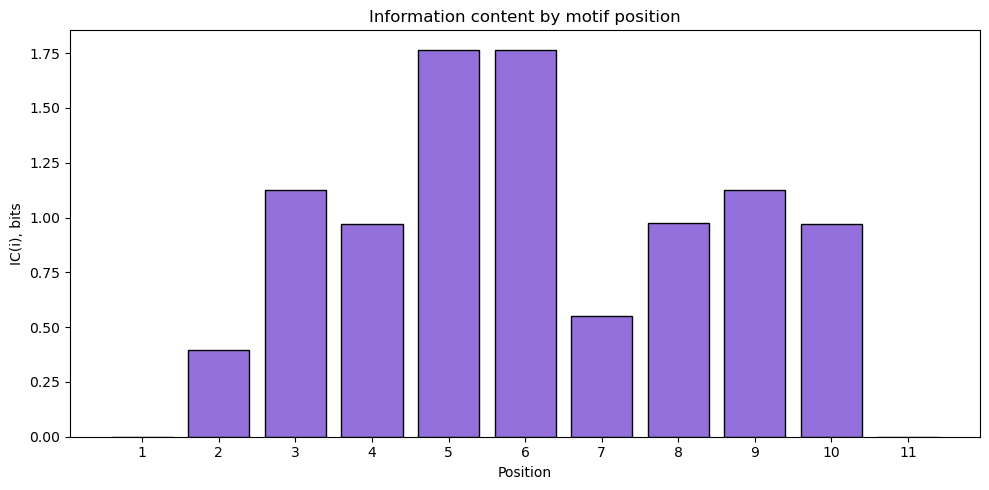

In [2]:

# копипаста из прошлых заданий
pwm = np.array([
    [-0.23878686, -1.47979496,  1.40062343, -1.47979496, -4.93922658,
     -4.93922658, -0.54690915,  1.21052054, -0.54690915, -1.47979496,
     -0.23878686],

    [ 0.28630419,  1.5166018 , -0.02181811, -0.95470391, -4.41413553,
     -4.41413553,  1.5166018 , -4.41413553, -4.41413553,  1.92571447,
      0.28630419],

    [ 0.28630419, -0.95470391, -4.41413553,  1.92571447,  2.24407595,
     -4.41413553, -4.41413553,  0.54006078,  1.92571447, -4.41413553,
      0.28630419],

    [-0.23878686, -0.54690915, -4.93922658, -4.93922658, -4.93922658,
      1.71898491, -0.54690915, -4.93922658, -4.93922658, -1.47979496,
     -0.23878686]
])


bg = np.array([0.295, 0.205, 0.205, 0.295])[:, None]   


ppm_unnorm = bg * (2 ** pwm)
ppm = ppm_unnorm / ppm_unnorm.sum(axis=0, keepdims=True)

# Энтропия Шеннона по позициям
with np.errstate(divide='ignore', invalid='ignore'):
    logp = np.where(ppm > 0, np.log2(ppm), 0.0)
    H = -np.sum(ppm * logp, axis=0)

# Информационное содержание
IC = 2 - H

positions = np.arange(1, ppm.shape[1] + 1)

print("Entropy H(i):")
for i, h in enumerate(H, start=1):
    print(f"Position {i}: {h:.4f}")

print("\nInformation content IC(i):")
for i, ic in enumerate(IC, start=1):
    print(f"Position {i}: {ic:.4f}")


plt.figure(figsize=(10, 5))
plt.bar(positions, IC, color='mediumpurple', edgecolor='black')
plt.xlabel('Position')
plt.ylabel('IC(i), bits')
plt.title('Information content by motif position')
plt.xticks(positions)
plt.tight_layout()
plt.show()
